In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, LinearRegression
import xgboost as xgb
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import joblib
import csv

### Data Preprocessing

In [3]:
df = pd.read_csv("./datasets/new_raw.csv")
first = ["name", "nvar"]
df = df[first + [c for c in df.columns if c not in first]]
df["nvar"].value_counts
df = df.sort_values(["name", "nvar", "mem"]).reset_index()
df

,index,name,nvar,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,dual_feas,status,timed_bytes,timed_time,timed_gctime,nlp_warmup_time,mem,neval_grad,iter,source_solver,problem,neval_obj,timestamp_solver,error_solver,vector_type,extract_duration_problem,highest_degree (ExprTree),nln_nnzj,adbackend_hessian_backend_type,minimize,count_plus_minus,alloc_obj,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,tree_length,count_trigonometric_function,matrix_free,nlin,time_obj,tree_depth,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,count_exponential_function,islp,count_op_function,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,time_grad,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,eval_duration_problem,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,15939,arglina,100,1.0,5.000000e+01,0.319062,0.011306,0.000135,7.841650e-15,first_order,18576.0,0.000164,0.000000,0.377710,1,4.0,1.0,OptimizationProb...,OptimizationProb...,4.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
1,15940,arglina,100,1.0,5.000000e+01,0.319062,0.011309,0.000151,7.841650e-15,first_order,22120.0,0.000199,0.000000,0.377710,2,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
2,15941,arglina,100,1.0,5.000000e+01,0.319062,0.011275,0.000140,7.841650e-15,first_order,25592.0,0.000182,0.000000,0.377710,3,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModel

### Identify the features and targets for this model

In [9]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "mem",
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "extract_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

group_key = ["name", "nvar"]
all_cols = list(set(feature_cols_reg + target_cols_reg + target_col_model + group_key))
solver_metrics = ['neval_grad', 'neval_obj', 'timed_bytes']
df[solver_metrics] = df[solver_metrics].fillna(0)
df = df[all_cols]
df.isna().sum().sort_values(ascending=False)

count_exponential_function      0
count_op_function               0
mem                             0
total_alloc                     0
tree_length                     0
name                            0
count_plus_minus                0
extract_duration_problem        0
highest_degree (ExprTree)       0
time_obj                        0
timed_bytes                     0
neval_obj                       0
alloc_grad                      0
time_grad                       0
count_trigonometric_function    0
stats_elapsed_time              0
nvar                            0
tree_depth                      0
alloc_obj                       0
neval_grad                      0
dtype: int64

In [10]:
df = df.copy()
df["mem_count"] = df.groupby(["name", "nvar"]).transform('size')
df = df[df["mem_count"] == 100].copy().reset_index(drop=True)
df

,count_exponential_function,count_op_function,alloc_obj,tree_depth,nvar,stats_elapsed_time,count_trigonometric_function,time_grad,alloc_grad,neval_obj,timed_bytes,time_obj,highest_degree (ExprTree),extract_duration_problem,count_plus_minus,name,tree_length,total_alloc,mem,neval_grad,mem_count
0,0.0,509.0,34515160.0,9.0,100,0.000135,0.0,0.464686,4.261110e+07,4.0,18576.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,7.712626e+07,1,4.0,100
1,0.0,509.0,34515160.0,9.0,100,0.000151,0.0,0.464686,4.261110e+07,2.0,22120.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,7.712626e+07,2,2.0,100
2,0.0,509.0,34515160.0,9.0,100,0.000140,0.0,0.464686,4.261110e+07,2.0,25592.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,7.712626e+07,3,2.0,100
3,0.0,509.0,34515160.0,9.0,100,0.000151,0.0,0.464686,4.261110e+07,2.0,29128.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,7.712626e+07,4,2.0,100
4,0.0,509.0,34515160.0,9.0,100,0.000139,0.0,0.464686,4.261110e+07,2.0,32600.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,7.712626e+07,5,2.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21495,0.0,575001.0,65309368.0,7.0,100000,1279.820757,0.0,35.399378,2.573195e+10,68.0,314448744.0,0.073713,2.0,2813.283680,275001.0,woods,425000.0,2.579726e+10,96,59.0,100
21496,0.0,575001.0,65309368.0,7.0,100000,1112.816634,0.0,35.399378,2.573195e+10,68.0,317646328.0,0.073713,2.0,2813.283680,275001.0,woods,425000.0,2.579726e+10,97,59.0,100
21497,0.0,575001.0,65309368.0,7.0,100000,1162.156092,0.0,35.399378,2.573195e+10,68.0,320848008.0,0.073713,2.0,2813.283680,275001.0,woods,425000.0,2.579726e+10,98,59.0,100
21498,0.0,575001.0,65309368.0,7.0,100000,1396.521273,0.0,35.399378,2.573195e+10,68.0,324045592.0,0.073713,2.0,2813.283680,275001.0,woods,425000.0,2.579726e+10,99,59.0,100


In [11]:
# unique instances: one row per (problem, nvar)
instances = df[group_key].drop_duplicates()

# shuffle instances
instances = instances.sample(frac=1, random_state=66).reset_index(drop=True)

n = len(instances)
n_train = int(0.8 * n)

train_inst = instances.iloc[:n_train]
test_inst  = instances.iloc[n_train:]

# assign rows to splits by (problem, nvar)
train_df = df.merge(train_inst, on=["nvar", "name"], how="inner").reset_index(drop=True)
test_df  = df.merge(test_inst,  on=["nvar", "name"], how="inner").reset_index(drop=True)
all_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
all_df

,count_exponential_function,count_op_function,alloc_obj,tree_depth,nvar,stats_elapsed_time,count_trigonometric_function,time_grad,alloc_grad,neval_obj,timed_bytes,time_obj,highest_degree (ExprTree),extract_duration_problem,count_plus_minus,name,tree_length,total_alloc,mem,neval_grad,mem_count
0,0.0,509.0,34515160.0,9.0,100,0.000135,0.0,0.464686,42611104.0,4.0,18576.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,77126264.0,1,4.0,100
1,0.0,509.0,34515160.0,9.0,100,0.000151,0.0,0.464686,42611104.0,2.0,22120.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,77126264.0,2,2.0,100
2,0.0,509.0,34515160.0,9.0,100,0.000140,0.0,0.464686,42611104.0,2.0,25592.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,77126264.0,3,2.0,100
3,0.0,509.0,34515160.0,9.0,100,0.000151,0.0,0.464686,42611104.0,2.0,29128.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,77126264.0,4,2.0,100
4,0.0,509.0,34515160.0,9.0,100,0.000139,0.0,0.464686,42611104.0,2.0,32600.0,0.376715,2.0,4.309682,305.0,arglina,10404.0,77126264.0,5,2.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21495,0.0,57501.0,75185144.0,7.0,10000,7.757891,0.0,1.054803,471227304.0,68.0,31484720.0,0.113105,2.0,74.643566,27501.0,woods,42500.0,546412448.0,96,59.0,100
21496,0.0,57501.0,75185144.0,7.0,10000,7.755893,0.0,1.054803,471227304.0,68.0,31804864.0,0.113105,2.0,74.643566,27501.0,woods,42500.0,546412448.0,97,59.0,100
21497,0.0,57501.0,75185144.0,7.0,10000,7.753765,0.0,1.054803,471227304.0,68.0,32125008.0,0.113105,2.0,74.643566,27501.0,woods,42500.0,546412448.0,98,59.0,100
21498,0.0,57501.0,75185144.0,7.0,10000,7.755922,0.0,1.054803,471227304.0,68.0,32445152.0,0.113105,2.0,74.643566,27501.0,woods,42500.0,546412448.0,99,59.0,100


In [12]:
X_train = train_df[feature_cols_reg].to_numpy(dtype=float)
X_test  = test_df[feature_cols_reg].to_numpy(dtype=float)

y_train = np.log1p(train_df[target_cols_reg].to_numpy(dtype=float))
y_test  = np.log1p(test_df[target_cols_reg].to_numpy(dtype=float))

X_all = np.concatenate([X_train, X_test], axis=0)

### Model Selection and Hyperparameter Tuning

### Stage 1: XGBoost (native multi-output) — predicting neval_obj, neval_grad, timed_bytes

`XGBRegressor` handles multi-output natively when `y` has shape `(n, k)` — no wrapper needed.

In [ ]:
# # Hyperparameter search for Stage 1 XGBoost
# # Uncomment to run

# param_distributions = {
#     'n_estimators':      randint(50, 500),
#     'learning_rate':     uniform(0.01, 0.29),      # [0.01, 0.30]
#     'max_depth':         randint(2, 10),
#     'subsample':         uniform(0.5, 0.5),         # [0.5, 1.0]
#     'colsample_bytree':  uniform(0.4, 0.6),         # [0.4, 1.0]
#     'min_child_weight':  randint(1, 20),
#     'gamma':             uniform(0, 0.5),
#     'reg_alpha':         uniform(0, 1.0),
#     'reg_lambda':        uniform(0.5, 2.0),
# }

# xgb_model = xgb.XGBRegressor(
#     tree_method='hist',
#     random_state=42,
#     n_jobs=1
# )

# random_search = RandomizedSearchCV(
#     xgb_model,
#     param_distributions=param_distributions,
#     n_iter=200,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=4,
#     random_state=42,
#     verbose=3
# )

# random_search.fit(X_train, y_train)

# print("\n" + "="*80)
# print("BEST RESULTS")
# print("="*80)
# print("Best parameters:", random_search.best_params_)
# print("Best CV score (neg MSE):", random_search.best_score_)
# print("Actual MSE:", -random_search.best_score_)

# results_df = pd.DataFrame(random_search.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time',
#             'param_n_estimators', 'param_learning_rate', 'param_max_depth',
#             'param_subsample', 'param_colsample_bytree', 'param_min_child_weight']
# print(results_df[top_cols].head(20).to_string())

# results_df.to_csv('xgb_randomsearch_stage1_results.csv', index=False)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 187, in _run_module_as_main
    mod_name, mod_spec, code = _get_module_details(mod_name, _Error)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 110, in _get_module_details
    __import__(pkg_name)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/joblib/__init__.py", line 114, in <module>
    from .memory import Memory
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/joblib/memory.py", line 12, in <module>
    import asyncio
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/asyncio/__init__.py", line 8, in <module>
    from .base_events import *
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/asyncio/base_events.py", line 23, in <module>
    import socket
  File "/Library/Frameworks/Python.framew

KeyboardInterrupt: 

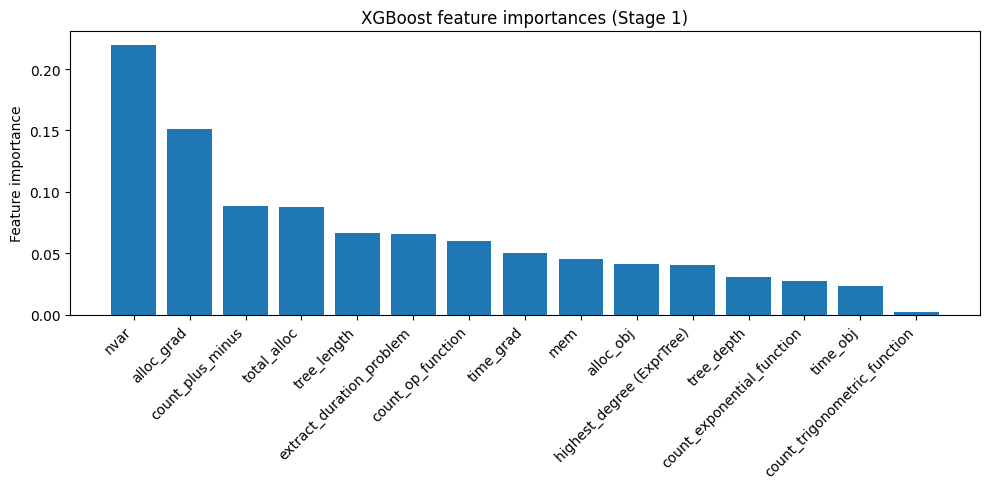

In [13]:
import matplotlib.pyplot as plt

best_model = joblib.load('./model_weights/best_xgb_model_reg.pkl')
# best_model = random_search.best_estimator_

xgb_importances = best_model.feature_importances_
indices_xgb = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols_reg)), xgb_importances[indices_xgb])
plt.xticks(range(len(feature_cols_reg)), [feature_cols_reg[i] for i in indices_xgb], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("XGBoost feature importances (Stage 1)")
plt.tight_layout()
plt.show()

# joblib.dump(best_model, './model_weights/best_xgb_model_reg.pkl')

In [14]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, pred)
test_r2  = r2_score(y_test, pred)
print(f"Gradient Boosting Stage1: MSE={test_mse:.4f}  R\u00b2={test_r2:.4f}")

relative_error = np.abs(pred - y_test) / np.abs(y_test + 1e-8)

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_cols_reg):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error[:, i] < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

Gradient Boosting Stage1: MSE=1.8625  R²=0.4179

neval_obj:
Relative Error | Under Threshold | Percentage
  <   5%:  13.26%
  <  10%:  34.30%
  <  15%:  41.74%
  <  20%:  54.02%
  <  30%:  66.09%
  <  50%:  90.44%

neval_grad:
Relative Error | Under Threshold | Percentage
  <   5%:  11.77%
  <  10%:  23.58%
  <  15%:  37.77%
  <  20%:  47.93%
  <  30%:  61.12%
  <  50%:  85.65%

timed_bytes:
Relative Error | Under Threshold | Percentage
  <   5%:  73.05%
  <  10%:  92.79%
  <  15%:  97.79%
  <  20%:  99.35%
  <  30%:  99.98%
  <  50%:  99.98%


### Stage 2: Using the **predicted** values of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [15]:
X_train_time = best_model.predict(X_train)
X_test_time  = best_model.predict(X_test)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time  = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [16]:
# Quick sanity check with default XGBoost
time_predictor = xgb.XGBRegressor(tree_method='hist', random_state=42)
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.17534136497008157

In [ ]:
# Hyperparameter search for Stage 2 XGBoost (predicted inputs)
# Uncomment to run

param_distributions = {
    'n_estimators':      randint(50, 500),
    'learning_rate':     uniform(0.01, 0.29),
    'max_depth':         randint(2, 10),
    'subsample':         uniform(0.5, 0.5),
    'colsample_bytree':  uniform(0.4, 0.6),
    'min_child_weight':  randint(1, 20),
    'gamma':             uniform(0, 0.5),
    'reg_alpha':         uniform(0, 1.0),
    'reg_lambda':        uniform(0.5, 2.0),
}

xgb_model = xgb.XGBRegressor(tree_method='hist', random_state=42, n_jobs=1)

time_random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=200,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=4,
    random_state=42,
    verbose=3,
    return_train_score=True,
    error_score='raise'
)

time_random_search.fit(X_train_time, y_train_time)

print("\n" + "="*80)
print("BEST RESULTS")
print("="*80)
print("Best parameters:", time_random_search.best_params_)
print("Best CV score (neg MSE):", time_random_search.best_score_)
print("Actual MSE:", -time_random_search.best_score_)

results_df = pd.DataFrame(time_random_search.cv_results_)
results_df['actual_mse'] = -results_df['mean_test_score']
results_df = results_df.sort_values('actual_mse')

top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time',
            'param_n_estimators', 'param_learning_rate', 'param_max_depth',
            'param_subsample', 'param_colsample_bytree', 'param_min_child_weight']
print(results_df[top_cols].head(20).to_string())

results_df.to_csv('xgb_randomsearch_stage2_pred_results.csv', index=False)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV 1/5] END colsample_bytree=0.6247240713084175, gamma=0.4753571532049581, learning_rate=0.22227824312530747, max_depth=6, min_child_weight=7, n_estimators=171, reg_alpha=0.15599452033620265, reg_lambda=0.6161672243363989, subsample=0.9330880728874675;, score=(train=-0.159, test=-3.010) total time=   0.1s
[CV 2/5] END colsample_bytree=0.6247240713084175, gamma=0.4753571532049581, learning_rate=0.22227824312530747, max_depth=6, min_child_weight=7, n_estimators=171, reg_alpha=0.15599452033620265, reg_lambda=0.6161672243363989, subsample=0.9330880728874675;, score=(train=-0.126, test=-3.180) total time=   0.1s
[CV 3/5] END colsample_bytree=0.6247240713084175, gamma=0.4753571532049581, learning_rate=0.22227824312530747, max_depth=6, min_child_weight=7, n_estimators=171, reg_alpha=0.15599452033620265, reg_lambda=0.6161672243363989, subsample=0.9330880728874675;, score=(train=-0.164, test=-2.396) total time=   0.0s
[CV 4/5] END

In [17]:
time_best_model = joblib.load('./model_weights/best_xgb_model_time.pkl')
# time_best_model = time_random_search.best_estimator_
accuracy = time_best_model.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model, './model_weights/best_xgb_model_time.pkl')

Time prediction accuracy based on predicted values=0.4512027315481235


['./model_weights/best_xgb_model_time.pkl']

In [18]:
pred = time_best_model.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R\u00b2={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=2.4785  R²=0.4512

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  5.63%
  <  10%:  10.56%
  <  15%:  12.86%
  <  20%:  14.14%
  <  30%:  18.91%
  <  50%:  26.44%


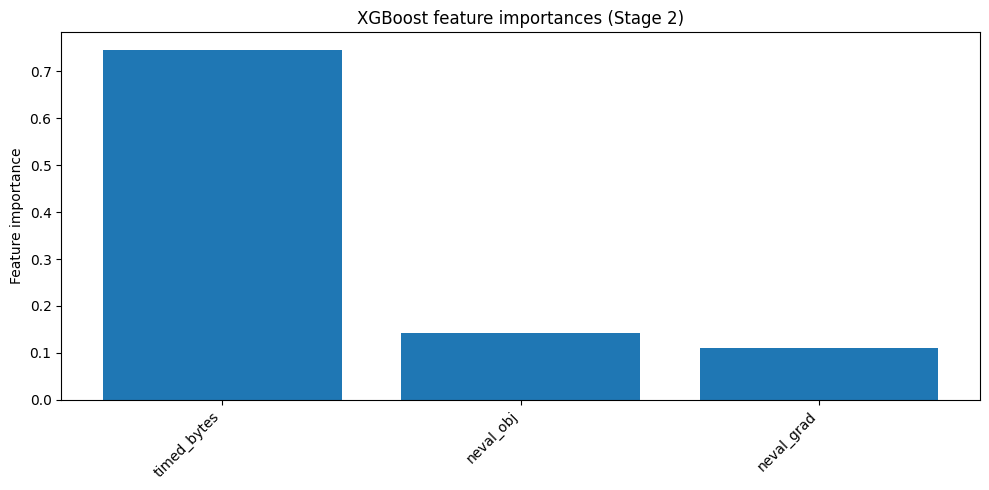

In [19]:
xgb_importances_time = time_best_model.feature_importances_
indices_xgb = np.argsort(xgb_importances_time)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), xgb_importances_time[indices_xgb])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_xgb], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("XGBoost feature importances (Stage 2)")
plt.tight_layout()
plt.show()

### Stage 2 (variant): Using the **actual** values of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [ ]:
X_train_time = train_df[target_cols_reg]
X_test_time  = test_df[target_cols_reg]
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time  = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [ ]:
# Quick sanity check with default XGBoost
time_predictor = xgb.XGBRegressor(tree_method='hist', random_state=42)
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.5674599310794721

In [ ]:
# Hyperparameter search for Stage 2 XGBoost (raw inputs)
# Uncomment to run

param_distributions = {
    'n_estimators':      randint(50, 500),
    'learning_rate':     uniform(0.01, 0.29),
    'max_depth':         randint(2, 10),
    'subsample':         uniform(0.5, 0.5),
    'colsample_bytree':  uniform(0.4, 0.6),
    'min_child_weight':  randint(1, 20),
    'gamma':             uniform(0, 0.5),
    'reg_alpha':         uniform(0, 1.0),
    'reg_lambda':        uniform(0.5, 2.0),
}

xgb_model = xgb.XGBRegressor(tree_method='hist', random_state=42, n_jobs=1)

time_random_search_raw = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=200,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=6,
    random_state=42,
    verbose=2,
    return_train_score=True,
    error_score='raise'
)

time_random_search_raw.fit(X_train_time, y_train_time)

print("\n" + "="*80)
print("BEST RESULTS")
print("="*80)
print("Best parameters:", time_random_search_raw.best_params_)
print("Best CV score (neg MSE):", time_random_search_raw.best_score_)
print("Actual MSE:", -time_random_search_raw.best_score_)

results_df = pd.DataFrame(time_random_search_raw.cv_results_)
results_df['actual_mse'] = -results_df['mean_test_score']
results_df = results_df.sort_values('actual_mse')

top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time',
            'param_n_estimators', 'param_learning_rate', 'param_max_depth',
            'param_subsample', 'param_colsample_bytree', 'param_min_child_weight']
print(results_df[top_cols].head(20).to_string())

results_df.to_csv('xgb_randomsearch_stage2_raw_results.csv', index=False)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END colsample_bytree=0.6247240713084175, gamma=0.4753571532049581, learning_rate=0.22227824312530747, max_depth=6, min_child_weight=7, n_estimators=171, reg_alpha=0.15599452033620265, reg_lambda=0.6161672243363989, subsample=0.9330880728874675; total time=   0.1s
[CV] END colsample_bytree=0.6247240713084175, gamma=0.4753571532049581, learning_rate=0.22227824312530747, max_depth=6, min_child_weight=7, n_estimators=171, reg_alpha=0.15599452033620265, reg_lambda=0.6161672243363989, subsample=0.9330880728874675; total time=   0.1s
[CV] END colsample_bytree=0.6247240713084175, gamma=0.4753571532049581, learning_rate=0.22227824312530747, max_depth=6, min_child_weight=7, n_estimators=171, reg_alpha=0.15599452033620265, reg_lambda=0.6161672243363989, subsample=0.9330880728874675; total time=   0.1s
[CV] END colsample_bytree=0.6247240713084175, gamma=0.4753571532049581, learning_rate=0.22227824312530747, max_depth=6, min_child

In [ ]:
time_best_model_raw = joblib.load('./model_weights/best_xgb_model_time_raw.pkl')
# time_best_model_raw = time_random_search_raw.best_estimator_
accuracy = time_best_model_raw.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on raw values={accuracy}")

joblib.dump(time_best_model_raw, './model_weights/best_xgb_model_time_raw.pkl')

Time prediction accuracy based on raw values=0.7832760769721095


['./model_weights/best_xgb_model_time_raw.pkl']

In [ ]:
pred = time_best_model_raw.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"Gradient Boosting Stage2: MSE={test_mse:.4f}  R\u00b2={test_r2:.4f}")

# relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

# thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
# for i, col in enumerate(target_col_model):
#     print(f"\n{col}:")
#     print(f"Relative Error | Under Threshold | Percentage")
#     for t in thresholds:
#         rate = np.mean(relative_error < t)
#         print(f"  <{t:5.0%}:  {rate:.2%}")

Gradient Boosting Stage2: MSE=0.9788  R²=0.7833


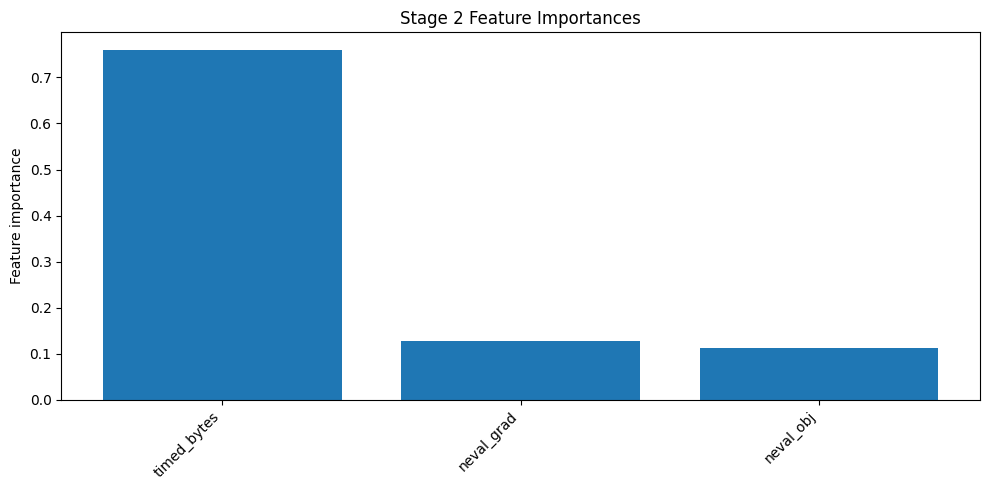

In [ ]:
xgb_importances_raw = time_best_model_raw.feature_importances_
indices_xgb = np.argsort(xgb_importances_raw)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), xgb_importances_raw[indices_xgb])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_xgb], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Stage 2 Feature Importances")
plt.tight_layout()
plt.show()

### Using linear regression model to predict time based on ["timed_bytes", "neval_grad", "neval_obj"]

In [ ]:
lr = LinearRegression()
lr_model = lr.fit(X_train_time, y_train_time)
accuracy = lr.score(X_test_time, y_test_time)
print(f"Default Linear Regression Model Test Accuracy={accuracy}")

Default Linear Regression Model Test Accuracy=-0.0068707623852164446


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'alpha': np.logspace(-3, 3, 100),
    'positive': [True, False],
    'fit_intercept': [True, False]
}

ridge_search = RandomizedSearchCV(
    Ridge(),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

ridge_search.fit(X_train_time, y_train_time)
print(f"Best params: {ridge_search.best_params_}")
print(f"Best CV R\u00b2: {ridge_search.best_score_}")
print(f"Test R\u00b2: {ridge_search.score(X_test_time, y_test_time)}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.1525e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.15045e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.11458e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=3.7427e-17): result may not be accur

Best params: {'positive': False, 'fit_intercept': True, 'alpha': 657.9332246575682}
Best CV R²: -8541.820120658334
Test R²: -0.006870756343572371


### Use stats_elapsed_time to find the best predicted mem value

In [ ]:
test_df["predicted_time"] = time_best_model_raw.predict(X_test_time)
test_df["predicted_time"]

0       0.344841
1      -0.094506
2      -0.094506
3      -0.094506
4      -0.094506
          ...   
4295    2.726250
4296    2.726250
4297    2.726250
4298    3.024994
4299    3.024994
Name: predicted_time, Length: 4300, dtype: float32

In [ ]:
group_cols = ["name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [ ]:
group_cols = ["name", "nvar"]
best_idx = test_df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_observed_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)
test_df["best_observed_time"] = test_df.groupby(group_cols)["stats_elapsed_time"].transform("min")

In [ ]:
group_cols = ["name", "nvar"]
best_idx = test_df.groupby(group_cols)["predicted_time"].idxmin()
model_time_map = test_df.loc[best_idx].set_index(group_cols)["stats_elapsed_time"]
best_mem_map   = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_predicted_time"] = test_df.set_index(group_cols).index.map(model_time_map)
test_df["best_predicted_mem"]  = test_df.set_index(group_cols).index.map(best_mem_map)

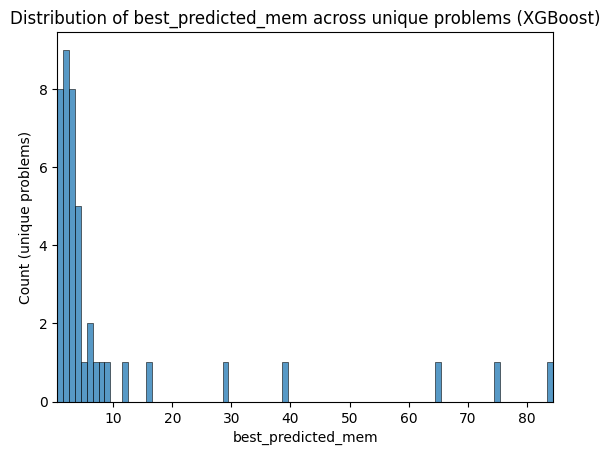

In [ ]:
import seaborn as sns
x = test_df.groupby(['name', 'nvar'])['best_predicted_mem'].first()
sns.histplot(x=x, discrete=True)
plt.xlim(0.5, x.max() + 0.5)
plt.xlabel("best_predicted_mem")
plt.ylabel("Count (unique problems)")
plt.title("Distribution of best_predicted_mem across unique problems (XGBoost)")
plt.show()

In [ ]:
test_df.groupby(['name', 'nvar'])[['best_predicted_mem', 'best_observed_mem', 'predicted_time', 'stats_elapsed_time', 'best_observed_time', 'best_predicted_time']].first()

,,best_predicted_mem,best_observed_mem,predicted_time,stats_elapsed_time,best_observed_time,best_predicted_time
name,nvar,,,,,,
arglinb,100,2,1,0.344841,0.000229,0.000229,0.000294
argtrig,100,9,61,0.854015,0.013453,0.008126,0.010001
arwhead,1000,3,3,0.618009,0.058931,0.040062,0.040062
brownal,100,1,1,0.247462,0.000280,0.000280,0.000280
brybnd,10000,1,1,1.609066,23.019709,23.019709,23.019709
clplatea,961,4,97,1.974938,16.738348,1.057629,3.078292
clplatec,100,75,87,5.159802,0.999100,0.012869,0.013983
cosine,100,2,1,0.341975,0.000634,0.000634,0.000641
cragglvy,1000,2,12,0.304316,0.415430,0.247496,0.319051


Proportions of best_predicted_mem:
best_predicted_mem
1     0.186047
2     0.209302
3     0.186047
4     0.116279
5     0.023256
6     0.046512
7     0.023256
8     0.023256
9     0.023256
12    0.023256
16    0.023256
29    0.023256
39    0.023256
65    0.023256
75    0.023256
84    0.023256
Name: proportion, dtype: float64


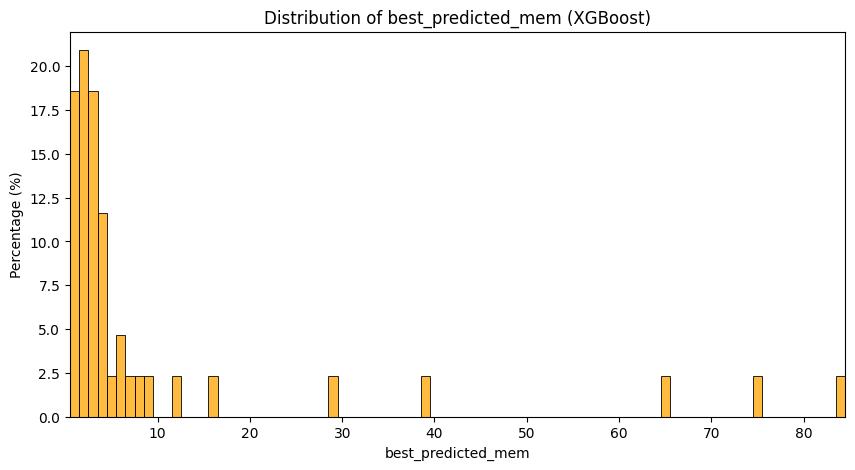

In [ ]:
x = test_df["best_predicted_mem"]
proportions = x.value_counts(normalize=True).sort_index()

print("Proportions of best_predicted_mem:")
print(proportions)

plt.figure(figsize=(10, 5))
sns.histplot(x=x, stat='percent', discrete=True, color='orange')
plt.xlabel("best_predicted_mem")
plt.ylabel("Percentage (%)")
plt.title("Distribution of best_predicted_mem (XGBoost)")
plt.xlim(0.5, x.max() + 0.5)
plt.show()

### Mem evaluation metrics

In [ ]:
mem_absolute_error = abs(test_df['best_predicted_mem'] - test_df['best_observed_mem'])
mame = np.mean(mem_absolute_error)
print(f"Mean Absolute Mem Error: {mame:.2f}")
print(f"Median Absolute Mem Error: {np.median(mem_absolute_error):.2f}")

Mean Absolute Mem Error: 30.63
Median Absolute Mem Error: 12.00


In [ ]:
mem_match_ratio = np.minimum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem']) / \
                  np.maximum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem'])

mean_match_ratio = np.mean(mem_match_ratio)
print(f"Mean Mem Match Ratio: {mean_match_ratio:.3f}")
# 1.0 = perfect match
# 0.5 = off by 2x
# 0.1 = off by 10x

Mean Mem Match Ratio: 0.379


In [ ]:
group_cols = ['name', 'nvar']
unique_problems = test_df.groupby(group_cols).first().reset_index()

print(f"Total unique test problems: {len(unique_problems)}\n")

Total unique test problems: 43



In [ ]:
print("="*60)
print("MEM PREDICTION ACCURACY")
print("="*60)

exact_match = (unique_problems['best_predicted_mem'] == unique_problems['best_observed_mem']).mean()
print(f"Exact match rate: {exact_match:.1%}")

within_5  = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 5).mean()
within_10 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 10).mean()
within_20 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 20).mean()

print(f"\nWithin tolerance:")
print(f"  \u00b1 5 mem units:  {within_5:.1%}")
print(f"  \u00b1 10 mem units: {within_10:.1%}")
print(f"  \u00b1 20 mem units: {within_20:.1%}")

MEM PREDICTION ACCURACY
Exact match rate: 14.0%

Within tolerance:
  ± 5 mem units:  37.2%
  ± 10 mem units: 46.5%
  ± 20 mem units: 55.8%


In [ ]:
print("="*60)
print("RANKING QUALITY")
print("="*60)

from scipy.stats import spearmanr

rank_corrs = []
for _, group_data in test_df.groupby(group_cols):
    true_order = group_data.sort_values('mem')['stats_elapsed_time'].values
    pred_order = group_data.sort_values('mem')['predicted_time'].values
    corr, _ = spearmanr(true_order, pred_order)
    rank_corrs.append(corr)

print(f"Mean Spearman correlation: {np.mean(rank_corrs):.3f}")
print(f"Median Spearman correlation: {np.median(rank_corrs):.3f}")

RANKING QUALITY
Mean Spearman correlation: 0.089
Median Spearman correlation: -0.049


### Baselines Comparisons

In [ ]:
df.columns

Index(['extract_duration_problem', 'eval_duration_problem', 'mem', 'time_obj',
       'time_grad', 'name', 'nvar', 'neval_obj', 'count_plus_minus',
       'total_alloc', 'neval_grad', 'count_op_function', 'alloc_grad',
       'stats_elapsed_time', 'count_exponential_function', 'alloc_obj',
       'highest_degree (ExprTree)', 'tree_depth', 'timed_bytes',
       'count_trigonometric_function', 'tree_length', 'mem_count',
       'best_observed_mem'],
      dtype='object')

In [ ]:
if 'baseline1_time' in test_df.columns:
    test_df = test_df.drop(columns='baseline1_time')
baseline1_values = df[df['mem'] == 5][['name', 'nvar', 'stats_elapsed_time']].drop_duplicates(['name', 'nvar'])
test_df = test_df.merge(
    baseline1_values.rename(columns={'stats_elapsed_time': 'baseline1_time'}), 
    on=['name', 'nvar'], 
    how='left'
)
test_df

,extract_duration_problem,eval_duration_problem,mem,time_obj,time_grad,name,nvar,neval_obj,count_plus_minus,total_alloc,neval_grad,count_op_function,alloc_grad,stats_elapsed_time,count_exponential_function,alloc_obj,highest_degree (ExprTree),tree_depth,timed_bytes,count_trigonometric_function,tree_length,mem_count,predicted_time,best_observed_mem,best_observed_time,best_predicted_time,best_predicted_mem,baseline1_time
0,6.859471,3.275820,1,0.288629,1.029701,arglinb,100,56.0,400.0,98224056.0,8.0,20600.0,52547568.0,0.000229,0.0,45676488.0,2.0,8.0,20176.0,0.0,40200.0,100,0.344841,1,0.000229,0.000294,2,0.000234
1,6.859471,3.275820,2,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000294,0.0,45676488.0,2.0,8.0,23720.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234
2,6.859471,3.275820,3,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000294,0.0,45676488.0,2.0,8.0,27192.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234
3,6.859471,3.275820,4,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000236,0.0,45676488.0,2.0,8.0,30728.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234
4,6.859471,3.275820,5,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000234,0.0,45676488.0,2.0,8.0,34200.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,74.643566,1.302962,96,0.113105,1.054803,woods,10000,68.0,27501.0,546412448.0,59.0,57501.0,471227304.0,7.757891,0.0,75185144.0,2.0,7.0,31484720.0,0.0,42500.0,100,2.726250,12,7.359282,9.051904,4,9.446440
4296,74.643566,1.302962,97,0.113105,1.054803,woods,10000,68.0,27501.0,546412448.0,59.0,57501.0,471227304.0,7.755893,0.0,75185144.0,2.0,7.0,31804864.0,0.0,42500.0,100,2.726250,12,7.359282,9.051904,4,9.446440
4297,74.643566,1.302962,98,0.113105,1.054803,woods,10000,68.0,27501.0,546412448.0,59.0,57501.0,471227304.0,7.753765,0.0,75185144.0,2.0,7.0,32125008.0,0.0,42500.0,100,2.726250,12,7.359282,9.051904,4,9.446440
4298,74.643566,1.302962,99,0.113105,1.054803,woods,10000,68.0,27501.0,546412448.0,59.0,57501.0,471227304.0,7.755922,0.0,75185144.0,2.0,7.0,32445152.0,0.0,42500.0,100,3.024994,12,7.359282,9.051904,4,9.446440


In [ ]:
GLOBAL_BEST_MEM = 87
if 'baseline2_time' in test_df.columns:
    test_df = test_df.drop(columns='baseline2_time')
baseline2_values = df[df['mem'] == GLOBAL_BEST_MEM][['name', 'nvar', 'stats_elapsed_time']].drop_duplicates(['name', 'nvar'])
test_df = test_df.merge(
    baseline2_values.rename(columns={'stats_elapsed_time': 'baseline2_time'}), 
    on=['name', 'nvar'], 
    how='left'
)
test_df

,extract_duration_problem,eval_duration_problem,mem,time_obj,time_grad,name,nvar,neval_obj,count_plus_minus,total_alloc,neval_grad,count_op_function,alloc_grad,stats_elapsed_time,count_exponential_function,alloc_obj,highest_degree (ExprTree),tree_depth,timed_bytes,count_trigonometric_function,tree_length,mem_count,predicted_time,best_observed_mem,best_observed_time,best_predicted_time,best_predicted_mem,baseline1_time,baseline2_time
0,6.859471,3.275820,1,0.288629,1.029701,arglinb,100,56.0,400.0,98224056.0,8.0,20600.0,52547568.0,0.000229,0.0,45676488.0,2.0,8.0,20176.0,0.0,40200.0,100,0.344841,1,0.000229,0.000294,2,0.000234,0.000289
1,6.859471,3.275820,2,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000294,0.0,45676488.0,2.0,8.0,23720.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
2,6.859471,3.275820,3,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000294,0.0,45676488.0,2.0,8.0,27192.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
3,6.859471,3.275820,4,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000236,0.0,45676488.0,2.0,8.0,30728.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
4,6.859471,3.275820,5,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000234,0.0,45676488.0,2.0,8.0,34200.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,74.643566,1.302962,96,0.113105,1.054803,woods,10000,68.0,27501.0,546412448.0,59.0,57501.0,471227304.0,7.757891,0.0,75185144.0,2.0,7.0,31484720.0,0.0,42500.0,100,2.726250,12,7.359282,9.051904,4,9.446440,7.757396
4296,74.643566,1.302962,97,0.113105,1.054803,woods,10000,68.0,27501.0,546412448.0,59.0,57501.0,471227304.0,7.755893,0.0,75185144.0,2.0,7.0,31804864.0,0.0,42500.0,100,2.726250,12,7.359282,9.051904,4,9.446440,7.757396
4297,74.643566,1.302962,98,0.113105,1.054803,woods,10000,68.0,27501.0,546412448.0,59.0,57501.0,471227304.0,7.753765,0.0,75185144.0,2.0,7.0,32125008.0,0.0,42500.0,100,2.726250,12,7.359282,9.051904,4,9.446440,7.757396
4298,74.643566,1.302962,99,0.113105,1.054803,woods,10000,68.0,27501.0,546412448.0,59.0,57501.0,471227304.0,7.755922,0.0,75185144.0,2.0,7.0,32445152.0,0.0,42500.0,100,3.024994,12,7.359282,9.051904,4,9.446440,7.757396


In [ ]:
test_df = test_df.rename(columns={'best_observed_time': 'oracle_time'})
test_df.head(41)

,extract_duration_problem,eval_duration_problem,mem,time_obj,time_grad,name,nvar,neval_obj,count_plus_minus,total_alloc,neval_grad,count_op_function,alloc_grad,stats_elapsed_time,count_exponential_function,alloc_obj,highest_degree (ExprTree),tree_depth,timed_bytes,count_trigonometric_function,tree_length,mem_count,predicted_time,best_observed_mem,oracle_time,best_predicted_time,best_predicted_mem,baseline1_time,baseline2_time
0,6.859471,3.27582,1,0.288629,1.029701,arglinb,100,56.0,400.0,98224056.0,8.0,20600.0,52547568.0,0.000229,0.0,45676488.0,2.0,8.0,20176.0,0.0,40200.0,100,0.344841,1,0.000229,0.000294,2,0.000234,0.000289
1,6.859471,3.27582,2,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000294,0.0,45676488.0,2.0,8.0,23720.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
2,6.859471,3.27582,3,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000294,0.0,45676488.0,2.0,8.0,27192.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
3,6.859471,3.27582,4,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000236,0.0,45676488.0,2.0,8.0,30728.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
4,6.859471,3.27582,5,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000234,0.0,45676488.0,2.0,8.0,34200.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
5,6.859471,3.27582,6,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000237,0.0,45676488.0,2.0,8.0,37736.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
6,6.859471,3.27582,7,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000235,0.0,45676488.0,2.0,8.0,41208.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
7,6.859471,3.27582,8,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000438,0.0,45676488.0,2.0,8.0,44744.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
8,6.859471,3.27582,9,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000426,0.0,45676488.0,2.0,8.0,48216.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289
9,6.859471,3.27582,10,0.288629,1.029701,arglinb,100,28.0,400.0,98224056.0,4.0,20600.0,52547568.0,0.000431,0.0,45676488.0,2.0,8.0,51752.0,0.0,40200.0,100,-0.094506,1,0.000229,0.000294,2,0.000234,0.000289


In [ ]:
# Model Regret (the mem predicted by XGBoost)
test_df['model_regret'] = test_df['best_predicted_time'] - test_df['oracle_time']

# Baseline 1 Regret (always using mem=5)
test_df['baseline1_regret'] = test_df['baseline1_time'] - test_df['oracle_time']

# Baseline 2 Regret (always using the best fixed mem found in training)
test_df['baseline2_regret'] = test_df['baseline2_time'] - test_df['oracle_time']
test_df_unique = test_df.groupby(["name", "nvar"]).first()

test_df[test_df["model_regret"] == test_df["model_regret"].max()].head(1)

,extract_duration_problem,eval_duration_problem,mem,time_obj,time_grad,name,nvar,neval_obj,count_plus_minus,total_alloc,neval_grad,count_op_function,alloc_grad,stats_elapsed_time,count_exponential_function,alloc_obj,highest_degree (ExprTree),tree_depth,timed_bytes,count_trigonometric_function,tree_length,mem_count,predicted_time,best_observed_mem,oracle_time,best_predicted_time,best_predicted_mem,baseline1_time,baseline2_time,model_regret,baseline1_regret,baseline2_regret
2200,6162.37814,0.4946,1,0.096466,29.78093,extrosnb,100000,49.0,200002.0,2.042682e+10,37.0,400002.0,2.033763e+10,981.899404,0.0,89189936.0,2.0,8.0,10419136.0,0.0,200001.0,100,2.244375,79,533.513211,981.899404,1,847.513074,544.588259,448.386193,313.999863,11.075048


In [ ]:
print("\n" + "="*40)
print("AVERAGE REGRET (SECONDS ABOVE ORACLE)")
print("="*40)
print(test_df_unique[['model_regret', 'baseline1_regret', 'baseline2_regret']].mean().to_string())

print("\n" + "="*40)
print("REGRET QUANTILES (50% / 75% / 95%)")
print("="*40)
print(test_df_unique[['model_regret', 'baseline1_regret', 'baseline2_regret']].quantile([0.5, 0.75, 0.95]))


AVERAGE REGRET (SECONDS ABOVE ORACLE)
model_regret        24.470105
baseline1_regret    25.146670
baseline2_regret     5.722437

REGRET QUANTILES (50% / 75% / 95%)
      model_regret  baseline1_regret  baseline2_regret
0.50      0.031325          0.267955          0.095412
0.75      3.157198          5.712914          0.670555
0.95     51.230463         67.109141         17.816225


In [ ]:
# Calculate ratios per problem (Relative Slowdown)
test_df_unique['model_ratio']     = test_df_unique['best_predicted_time'] / test_df_unique['oracle_time']
test_df_unique['baseline1_ratio'] = test_df_unique['baseline1_time'] / test_df_unique['oracle_time']
test_df_unique['baseline2_ratio'] = test_df_unique['baseline2_time'] / test_df_unique['oracle_time']

print("\n" + "="*40)
print("PERFORMANCE RATIO (1.0 = PERFECTION)")
print("="*40)
cols = ['model_ratio', 'baseline1_ratio', 'baseline2_ratio']
print(test_df_unique[cols].quantile([0.5, 0.75, 0.95]))


PERFORMANCE RATIO (1.0 = PERFECTION)
      model_ratio  baseline1_ratio  baseline2_ratio
0.50     1.175259         1.233671         1.111844
0.75     1.300717         1.782548         1.476112
0.95     2.135092         5.278511         2.266124
